## 5.2 합성곱 신경망 맛보기
**1) 필요한 라이브러리 불러오기 + 데이터 내려받기**
- 기본적으로 파이토치의 경우에는 GPU를 사용함.
- torchvision.datasets : torch.utils.data.Dataset의 하이 클래스를 포함함.

**2) 데이터를 DataLoader에 전달함.**
- torch.utils.data.DataLoader() : 원하는 크기의 배치 단위로 데이터를 불러오거나 순서가 무작위로 섞이도록 할 수 있음.
- np.random : 무작위로 데이터를 생성할때 사용함

**3) 심층신경망을 생성 -> 손실함수, 학습률, 옵티마이저 정의-> 학습 진행**
- 객체: 메모리를 할당받아 프로그램에서 사용되는 모든 데이터를 의미하기 때문에 변수, 함수 등을 모두 객체라고 할 수 있음.
- nn : 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지
- Linear: 단순 선형 회귀 모델을 만들때 사용함
- forward: 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시킴.
- view: 넘파이의 reshape과 같은 역할로 텐서의 크기를 변경해주는 역할을 함.
- autograd() : 자동 미분을 수행하는 핵심 패키지로 tape를 사용함

**4) 합성곱 신경망을 생성**
- nn.Sequential : __init()에서 사용할 네트워크 모델들을 정의해 줄 뿐만아니라 forward() 함수에서 구현될 순전파를 layer 형태로 작성함
- 합성곱: 합성곱 연산을 통해 이미지의 특징을 추출
- BatchNorm2d : 학습 과정에서 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화
- MaxPool2d: 이미지 크기를 축소시키는 용도 -> 크기를 줄이거나 특정 데이터를 강조

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전치를 위한 라이브러리
from torch.utils.data import Dataset, DataLoader

In [3]:
device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
train_dataset=torchvision.datasets.FashionMNIST('/content', download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset=torchvision.datasets.FashionMNIST('/content', download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.88MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]


In [5]:
train_loader=torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader=torch.utils.data.DataLoader(test_dataset, batch_size=100)

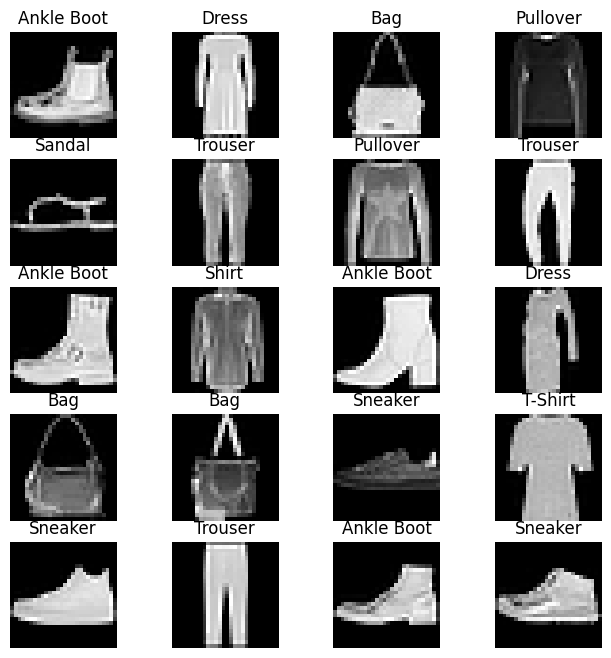

In [6]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4 : 'Coat', 5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker',
              8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8, 8));
columns = 4;
rows = 5;
for i in range(1, columns*rows+1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:];
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

In [7]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)
  def forward(self, input_data):
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

In [8]:
learning_rate = 0.001
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss(); # 분류에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))

        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()

        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

      if not (count % 500):
        print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5610656142234802, Accuracy: 83.2699966430664%
Iteration: 1000, Loss: 0.4656990170478821, Accuracy: 84.19000244140625%
Iteration: 1500, Loss: 0.3738270103931427, Accuracy: 84.27999877929688%
Iteration: 2000, Loss: 0.3849221169948578, Accuracy: 85.26000213623047%
Iteration: 2500, Loss: 0.24428939819335938, Accuracy: 85.9000015258789%
Iteration: 3000, Loss: 0.3331058919429779, Accuracy: 85.87000274658203%


In [10]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0),-1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [11]:
learning_rate = 0.001
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [12]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))

        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()

        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

      if not (count % 500):
        print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.4875393211841583, Accuracy: 87.5199966430664%
Iteration: 1000, Loss: 0.33512410521507263, Accuracy: 87.7699966430664%
Iteration: 1500, Loss: 0.35974636673927307, Accuracy: 87.7300033569336%
Iteration: 2000, Loss: 0.18369993567466736, Accuracy: 89.27999877929688%
Iteration: 2500, Loss: 0.11965534836053848, Accuracy: 89.41999816894531%
Iteration: 3000, Loss: 0.14744916558265686, Accuracy: 89.4800033569336%
